# Qualitative Comparison of fMCG Reconstrctions via Forward Model, ICA and Spatial FIltering on real-world Data

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import logging
import os
import sys
import numpy as np
import matplotlib.pyplot as plt

# Add the parent directory (which contains the fmcg package) to Python path
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import fmcg
from fmcg.signal.filtering import filternk
from fmcg.pipeline.preprocessing import load_and_preprocess
from fmcg.utils.plotting.plot_utils import plot_sensor_signals
from fmcg.analysis.hr import compute_hr
from fmcg.analysis.heartbeat_averaging import get_near_baseline_segments
from fmcg.ica.ics import ics
from fmcg.ica.ica_component_labeler import ICAComponentLabeler
from fmcg.spatial_filtering import SpatialFilter

logging.basicConfig(level=logging.ERROR, format="%(message)s", force=True)

## Data Loading and Preprocessing

Preprocessed signal: 297.1s at 200 Hz, 24 valid channels


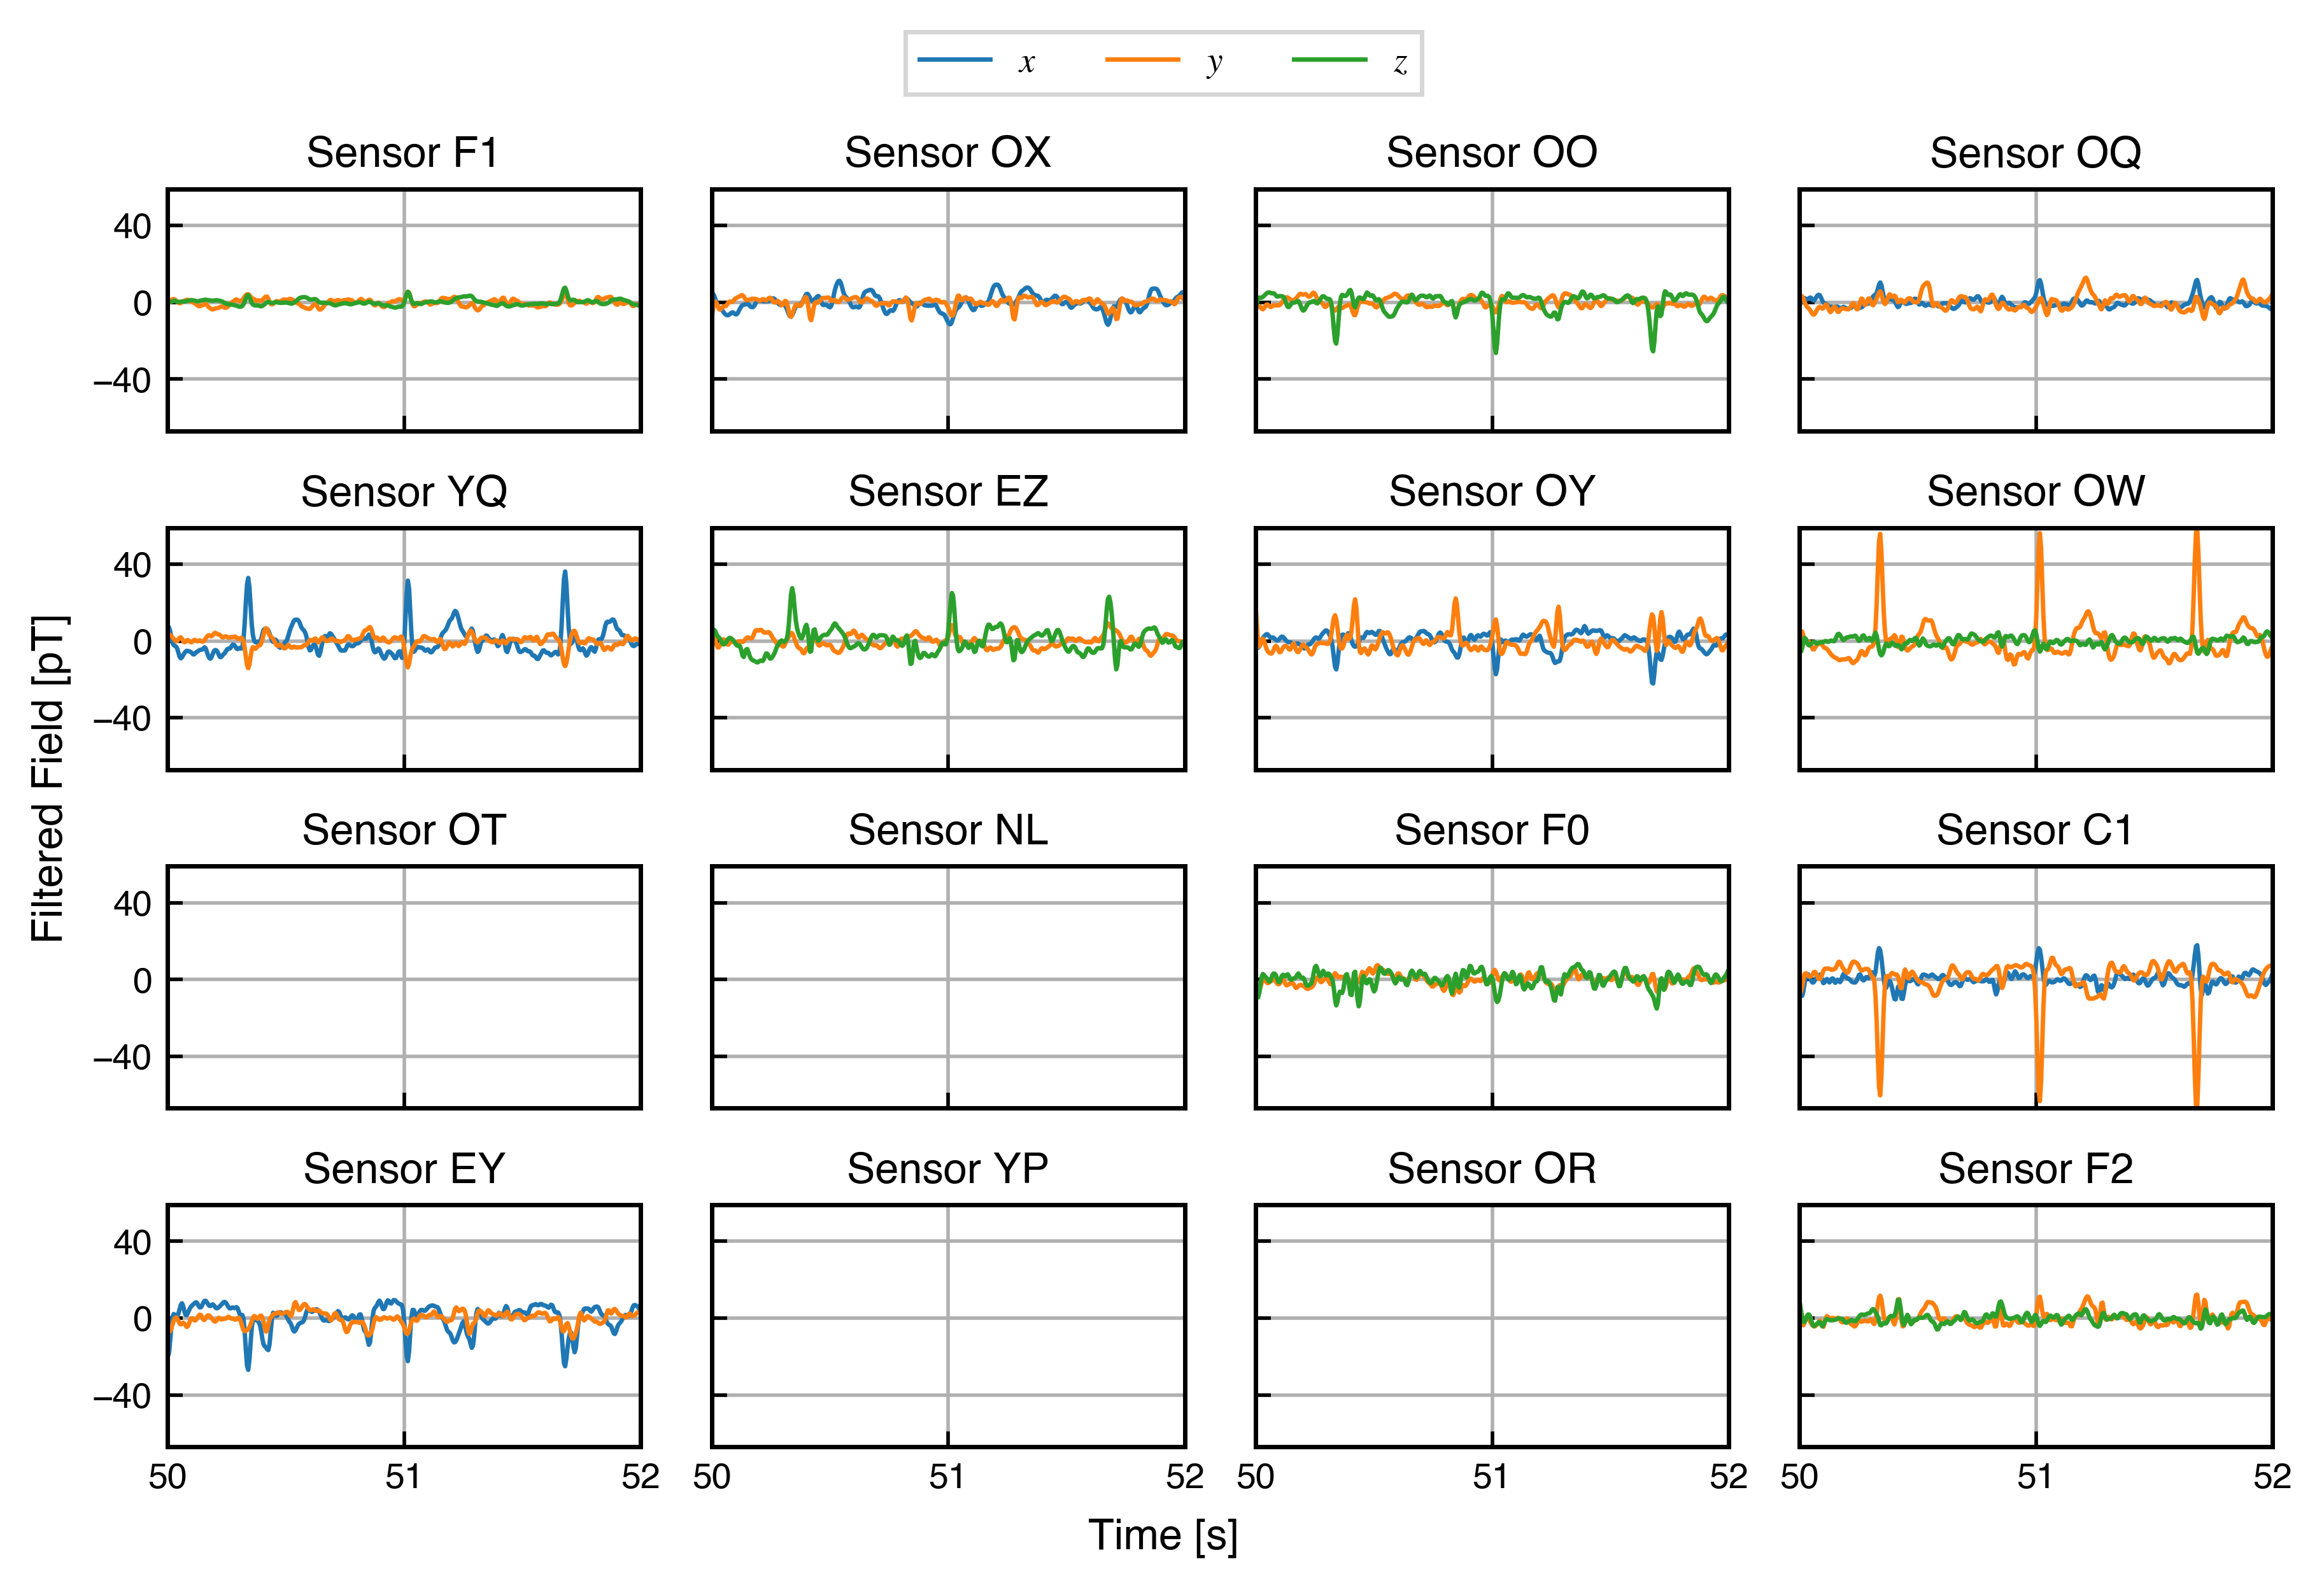

In [ ]:
DS_PATH = os.path.dirname(os.path.abspath(".")) + "/data"

(
    field_maps,
    noise_maps,
    axis_mask,
    W_n,
    fs,
    time,
    r_sensors,
    artifacts_mask,
    sensor_names,
) = load_and_preprocess(
    ds_path=DS_PATH,
    patient="P097",
    series="S07",
    sig_group_names="R001",
    noise_group_names="R004",
    whitening="PCA",
    downsample_factor=5,  # 1000 → 200 Hz
)

print(
    f"Preprocessed signal: {field_maps.shape[0]/fs:.1f}s at {fs} Hz, {int(axis_mask.sum())} valid channels"
)

plot_sensor_signals(
    field_maps,
    time,
    ylabel="Filtered Field [pT]",
    xlim=[50, 52],
    sharey=True,
    sensor_names=sensor_names,
)

## Baselines

### Annotate ICA References for Spatial Filtering and ICS

In [ ]:
%matplotlib widget
plt.close('all')

labeler = ICAComponentLabeler.from_filtered_signal(
      signal=field_maps,
      fs=fs,      
      time=time,
      axis_mask=axis_mask,        
      n_components=10,                                                       
      seed=42,
      xlim=(10, 15),                   
      canvas_size=("300px", "30px"),     
      fig_size=(8, 2),
      base_path="./_ica_annotation"
)                             
labeler.show()

Applying ICA...
Data shape before ICA: (59416, 24)
Extracted 10 ICA components
Launching ICA Component Labeler GUI...


In [20]:
plt.close('all')
%matplotlib inline

annotation = labeler.get_results()
sources = annotation['sources']                            
ica_mixing_ = annotation['mixing_matrix']                                      
fetals = np.where(np.array(annotation['component_labels']) == "Fetal")[0]
maternals = np.where(np.array(annotation['component_labels']) == "Maternal")[0]
sources = annotation["sources"]
ica = annotation['ica']

HR_f, peaks_f = compute_hr(sources, fs, fetals, plot=False)

### ICA based Reconstruction

In [6]:
# [1] Yu and Wakai, ‘Maternal MCG Interference Cancellation Using Splined Independent Component Subtraction’.

# # ICS [1]
# (requires complete annotation of maternal & noise components, otherwise residuals will remain after subtraction)
field_ICS, _ = ics(
    ica,
    field_maps[:, axis_mask],
    sources,
    maternals,
    fs,
    field_subtract=False,
    keep_sources=False,
)

# Splined ICS [1] (requires complete annotation of maternal & noise components, otherwise residuals will remain after subtraction)
field_sICS, _ = ics(
    ica,
    field_maps[:, axis_mask],
    sources,
    maternals,
    fs,
    field_subtract=True,
    keep_sources=True,
    spline=True,
)

### Spatial Filtering

In [ ]:
sf = SpatialFilter(
    method="lmmse",
    fs=fs,
    enhance={"sources": sources, "comps": fetals},
)
field_lmmse = sf.apply(field_maps[:, axis_mask])

# Forward Model

In [ ]:
from fmcg import Pipeline, PipelineConfig, SolverConfig, DataConfig, PreprocessingConfig

r_bnds = np.array(
    [
        [(-0.3, 0.3), (-0.3, -0.005), (-0.3, 0.3)],
        [(-0.3, 0.3), (-0.3, -0.005), (0.1, 0.6)],
    ]
)

r_init = r_init = np.array([[[0, -0.02, 0.0], [0, -0.05, 0.2]]])

# Create configuration
config = PipelineConfig(
    preprocessing=PreprocessingConfig(
        whitening="PCA",
        rescale_whitening=False,
        process_segments=False,
        min_segment_length=1,
        detect_artifacts=False,
        downsample_factor=5,
    ),
    data=DataConfig(
        ds_path=DS_PATH,
        patient="P097",
        series="S07",
        sig_group_names="R001",
        noise_group_names="R004",
        sampfrom=0,
        sampto=None,
    ),
    solver=SolverConfig(
        num_dipoles=2,
        optimizer="lamb",
        r_bnds=r_bnds,
        r_init=r_init,
    ),
    device="cuda:0",
)

# Use pipeline with context manager for automatic cleanup
with Pipeline() as pipeline:
    results = pipeline.run(config)
    field_forward = pipeline.get_forward_solution()

/opt/conda/lib/python3.11/site-packages/torch/cuda/__init__.py:827: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
Iterations: 100%|██████████| 800/800 [00:27<00:00, 28.67it/s, Best Loss=0.0922]


# Qualitative Comparison

### Reconstructed Field & Source Activity (no averaging)

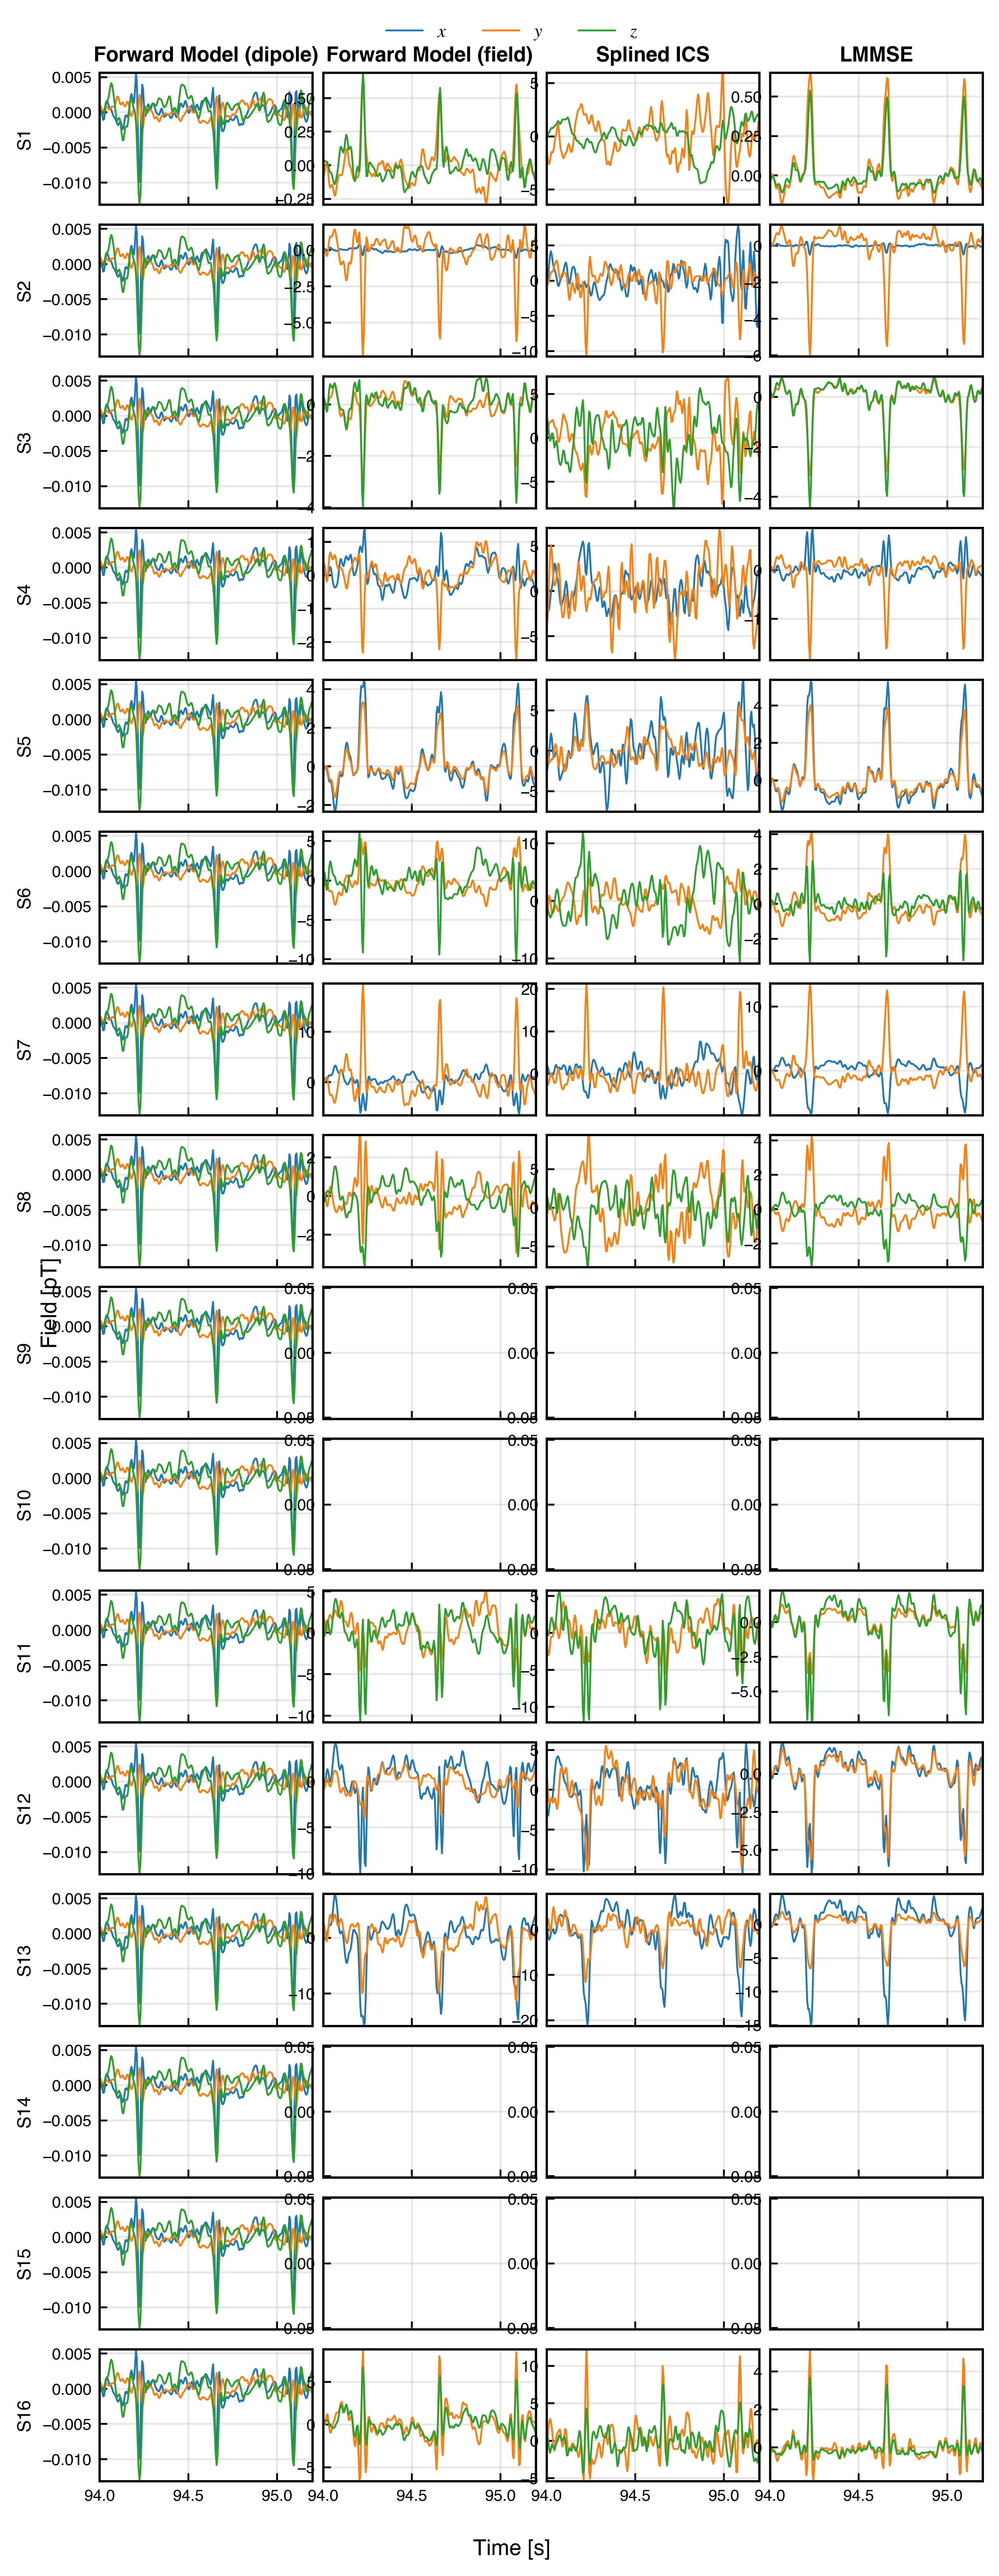

In [ ]:
from fmcg.utils.plotting.plot_utils import plot_sensor_signals_comparison

data = {
    "Forward Model (dipole)": np.repeat(
        pipeline.m_hat[:, 0:1], field_maps.shape[1], axis=1
    ),  # repeat the dipole moment across all sensors for comparison
    "Forward Model (field)": field_forward,
    "Splined ICS": field_sICS,
    "LMMSE": field_lmmse,
}

plot_sensor_signals_comparison(
    [
        fmcg.reduced2full(field, axis_mask) if field.ndim == 2 else field
        for field in data.values()
    ],
    field_labels=list(data.keys()),
    time=np.arange(field_maps.shape[0]) / fs,
    xlim=[94, 95.2],
    sharey=False,
)

### Averaged Field & Source

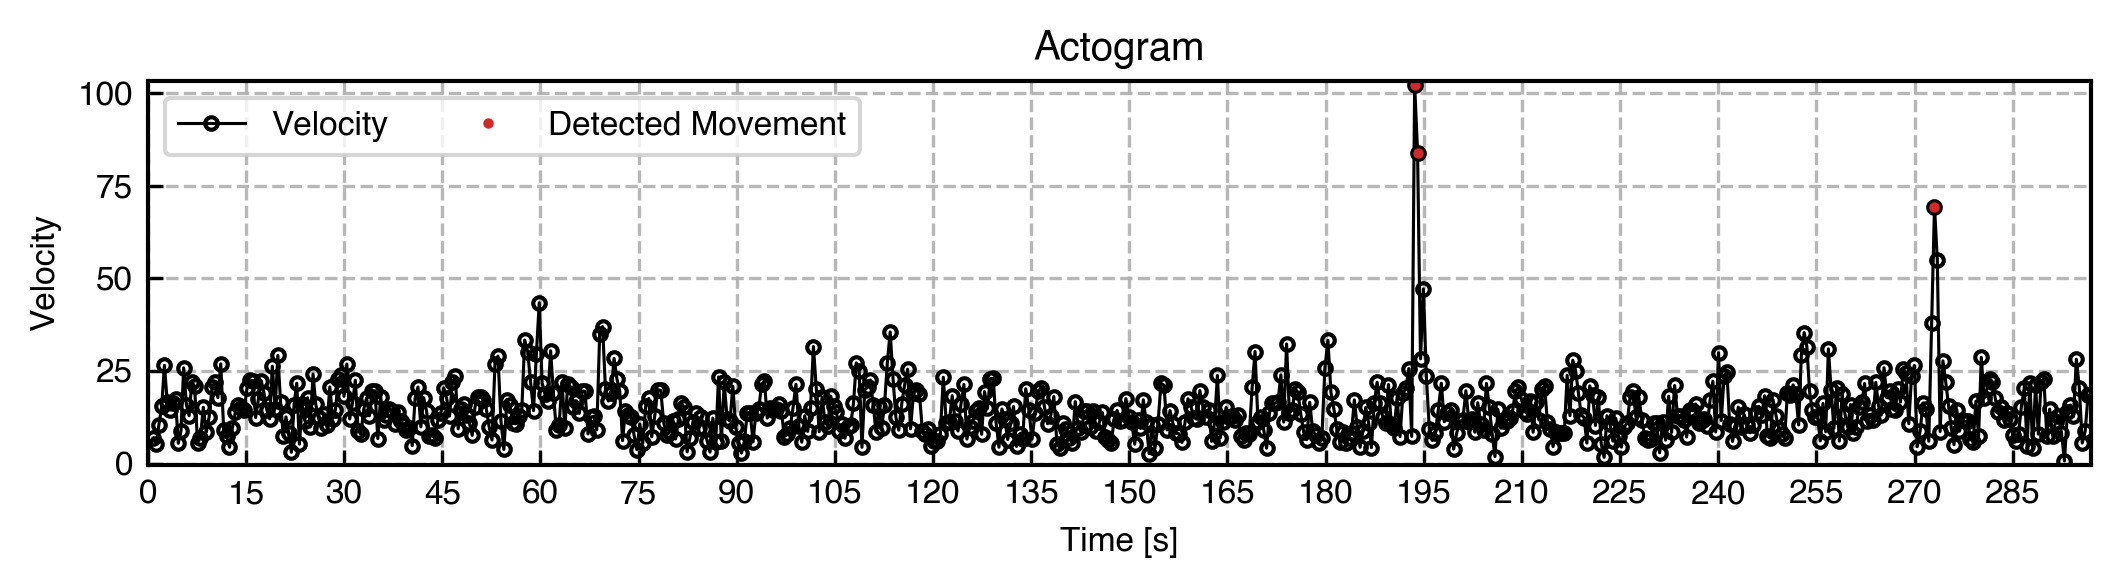

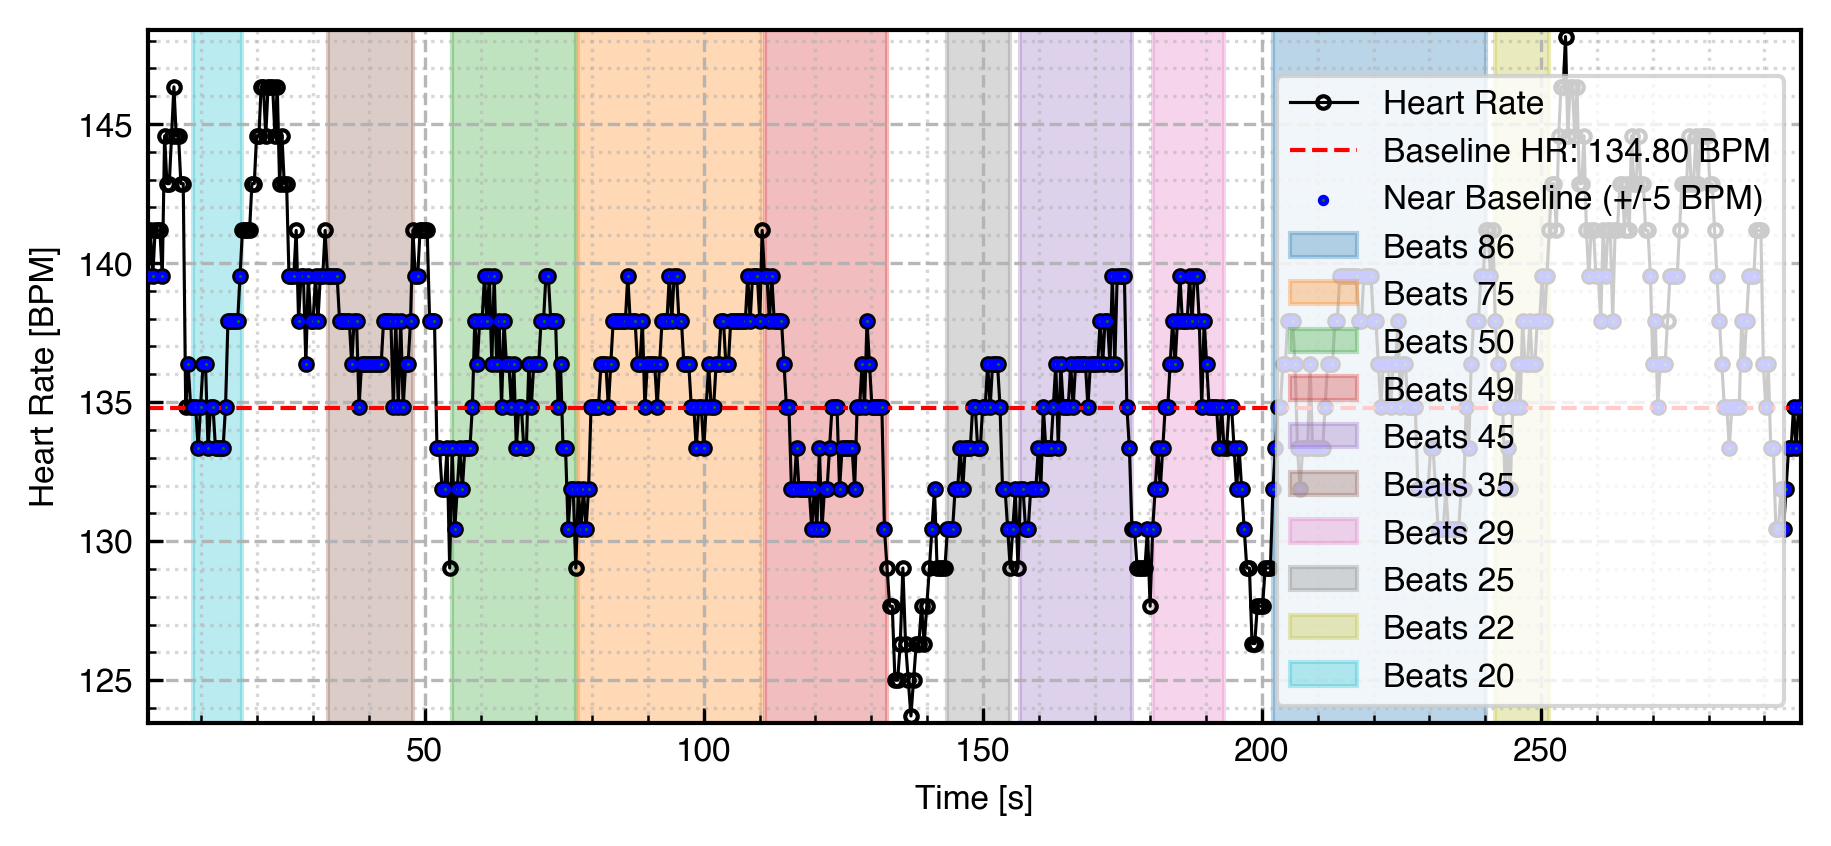

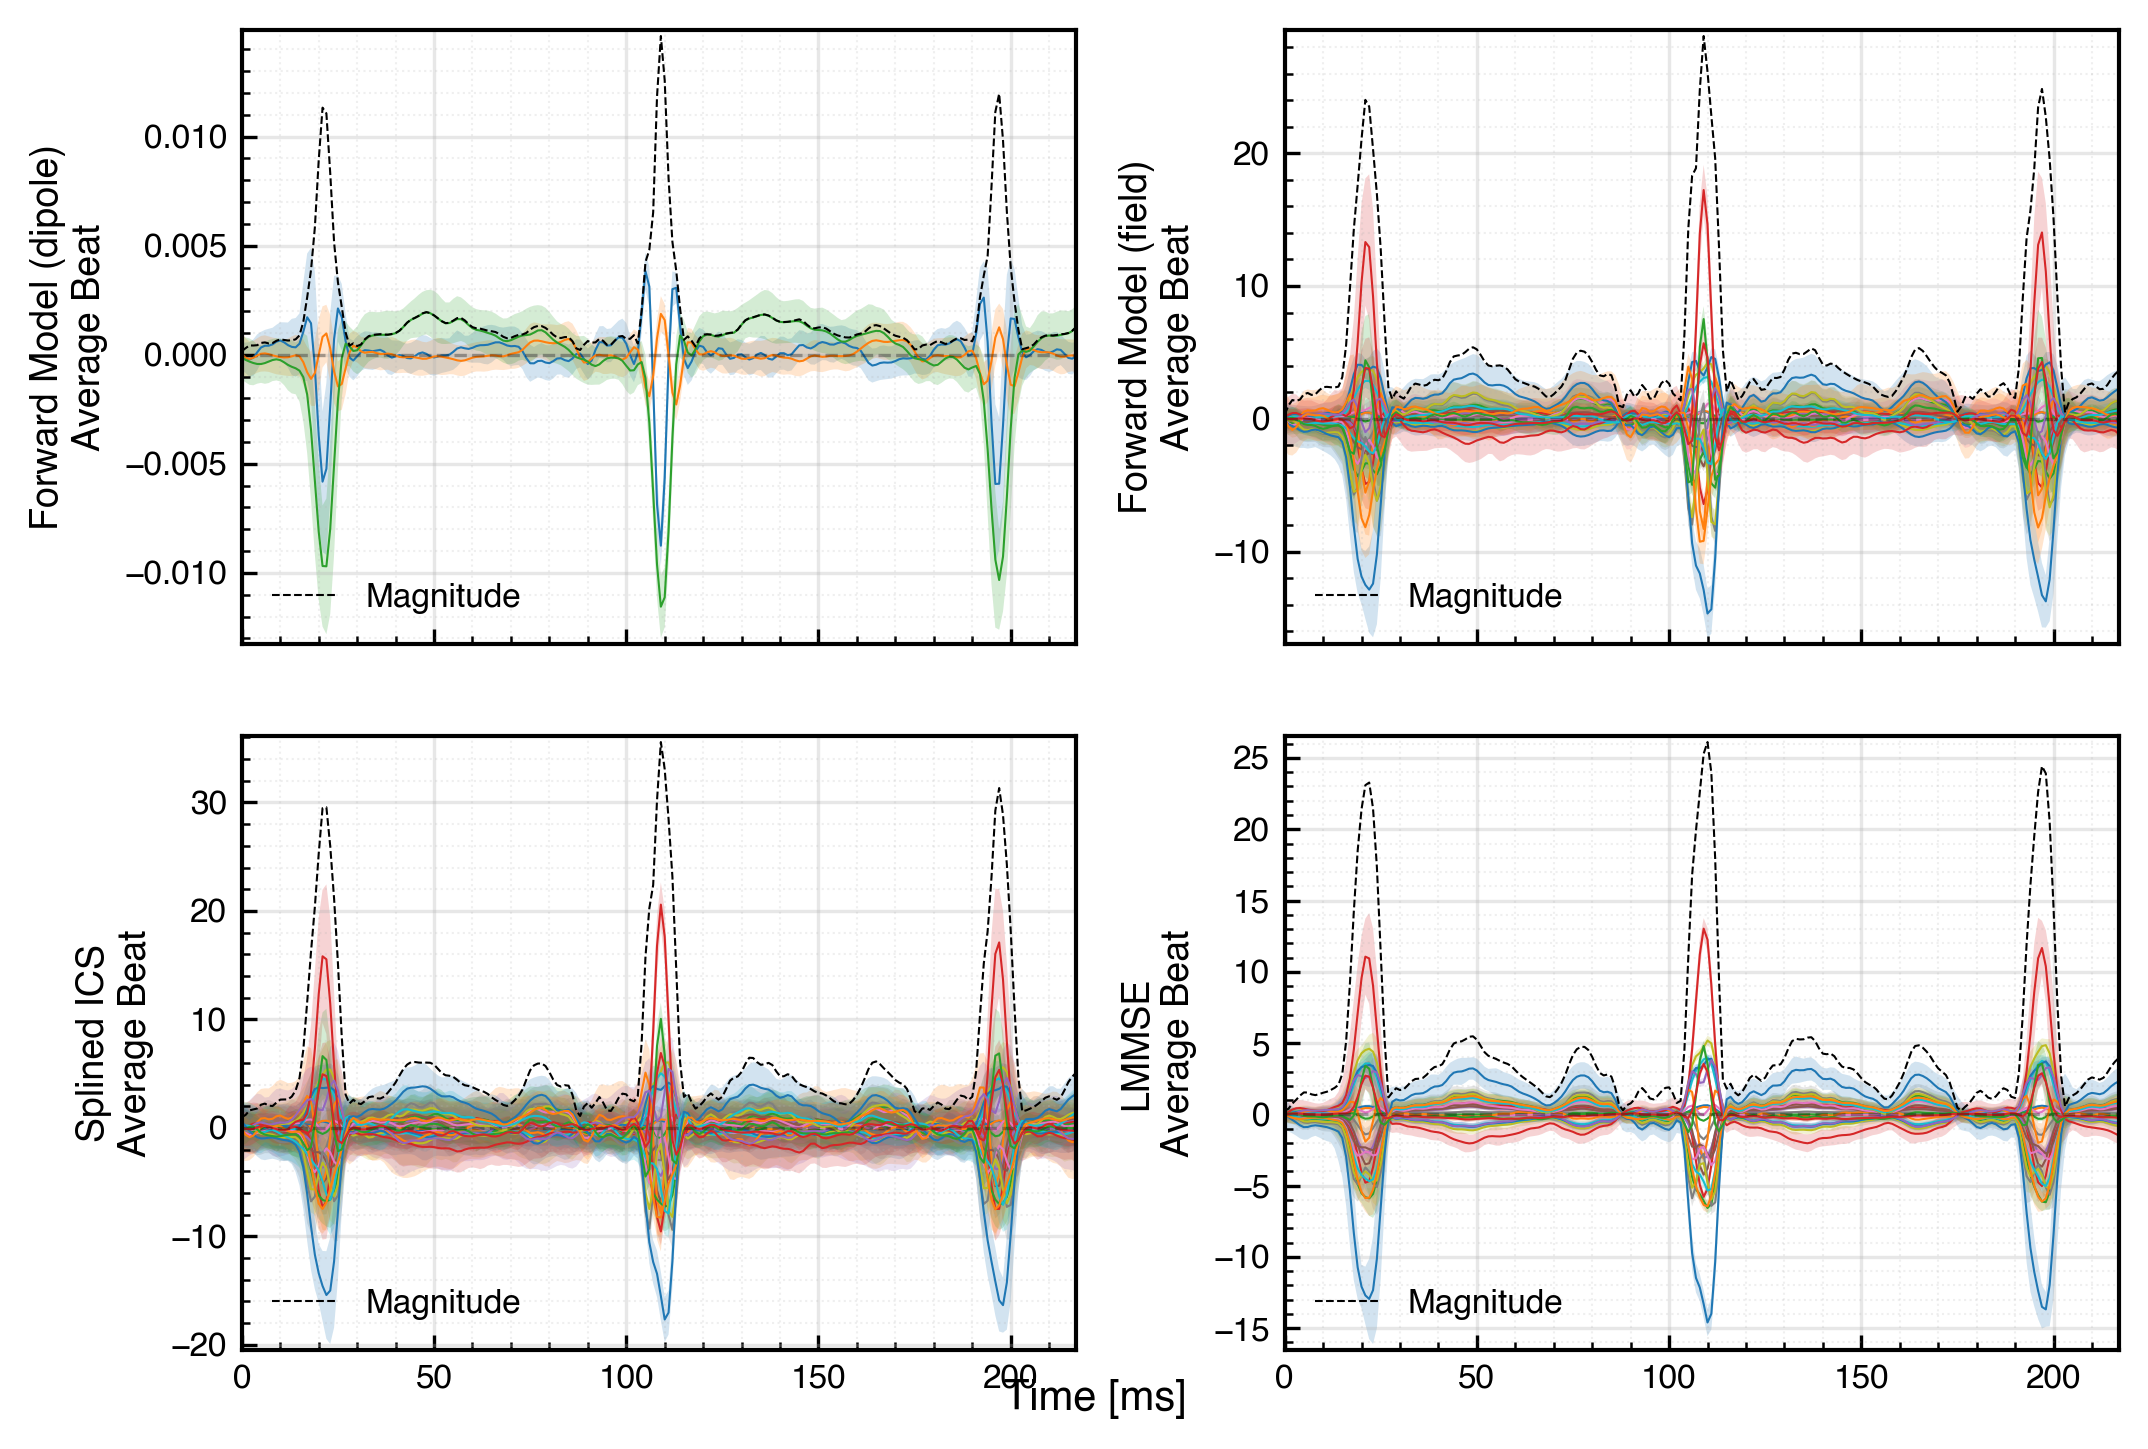

In [21]:
from fmcg.utils.plotting.plot_utils import plot_averaged_beats_comparison
from fmcg.analysis.heartbeat_averaging import average_heartbeats

segment_idx = 1  # Choose which hr segment to inspect
segments = get_near_baseline_segments(
    peaks_f, fs, signal=field_forward, plot=True
)


data = {
    "Forward Model (dipole)": pipeline.m_hat[:, 0],
    "Forward Model (field)": field_forward,
    "Splined ICS": field_sICS,
    "LMMSE": field_lmmse,
}

avg_beats = []
std_beats = []
_, start, end = segments[segment_idx]
for field_name, field in data.items():
    avg_waveform, std_waveform, _ = average_heartbeats(
        peaks_f[start:end] - peaks_f[start],
        field[peaks_f[start] : peaks_f[end]],
        fs,
        plot=False,
    )
    avg_beats.append(np.array(avg_waveform))
    std_beats.append(np.array(std_waveform))

plot_averaged_beats_comparison(
    avg_beats,
    std_beats,
    list(data.keys()),
    include_magnitude=True,
    ylabel="Average Beat",
    ncols=2,
    sharey=False,
)